In [10]:
import pandas as pd

In [11]:
df_books = pd.read_csv("books.csv")
df_ratings = pd.read_csv("ratings.csv")
df_to_read = pd.read_csv("to_read.csv")


print(df_books.head(3))
print(df_ratings.head(3))
print(df_to_read.head(3))

   book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   

                             original_title  ... ratings_count  \
0                          The Hunger Games  ...       4780653   
1  Harry Potter and the Philosopher's Stone  ...       4602479   
2                                  Twilight  ...       3866839   

  work_ratings_count  work_text_reviews_count  ratings_1  ratings_2  \
0            4942365                   155

In [12]:
manter_colunas = ["book_id", "books_count", "authors","original_publication_year", "title", "average_rating", "ratings_count"]
df_books = df_books[manter_colunas]
print(df_books.head(3))

   book_id  books_count                      authors  \
0        1          272              Suzanne Collins   
1        2          491  J.K. Rowling, Mary GrandPré   
2        3          226              Stephenie Meyer   

   original_publication_year  \
0                     2008.0   
1                     1997.0   
2                     2005.0   

                                               title  average_rating  \
0            The Hunger Games (The Hunger Games, #1)            4.34   
1  Harry Potter and the Sorcerer's Stone (Harry P...            4.44   
2                            Twilight (Twilight, #1)            3.57   

   ratings_count  
0        4780653  
1        4602479  
2        3866839  


In [13]:
df_books = df_books.rename(columns={
    "book_id": "id_livro",
    "books_count": "quantidade_livros",
    "authors": "autores",
    "original_publication_year": "ano_publicacao_original",
    "title": "titulo",
    "average_rating": "avaliacao_media",
    "ratings_count": "quantidade_avaliacoes"
})
print(df_books.head(3))

   id_livro  quantidade_livros                      autores  \
0         1                272              Suzanne Collins   
1         2                491  J.K. Rowling, Mary GrandPré   
2         3                226              Stephenie Meyer   

   ano_publicacao_original                                             titulo  \
0                   2008.0            The Hunger Games (The Hunger Games, #1)   
1                   1997.0  Harry Potter and the Sorcerer's Stone (Harry P...   
2                   2005.0                            Twilight (Twilight, #1)   

   avaliacao_media  quantidade_avaliacoes  
0             4.34                4780653  
1             4.44                4602479  
2             3.57                3866839  


In [22]:
df_books["ano_publicacao_original"] = pd.to_numeric(
    df_books["ano_publicacao_original"], errors="coerce"
).astype("Int64")

In [21]:
media_ratings = df_ratings.loc[df_ratings["book_id"] == 1, "rating"].mean()
media_books = df_books.loc[df_books["id_livro"] == 1, "avaliacao_media"]

print("Comparação de notas para book_id = 1")
print(f"Média no ratings: {media_ratings}")
print(f"Média no books: {media_books}")


Comparação de notas para book_id = 1
Média no ratings: 4.2797070946242215
Média no books: 0    4.34
Name: avaliacao_media, dtype: float64


In [23]:
df_filtro = df_books[
    (df_books["ano_publicacao_original"] >= 2000) &
    (df_books["ano_publicacao_original"] <= 2010)]

print(df_filtro)
     

      id_livro  quantidade_livros                          autores  \
0            1                272                  Suzanne Collins   
2            3                226                  Stephenie Meyer   
8            9                311                        Dan Brown   
10          11                283                  Khaled Hosseini   
15          16                274       Stieg Larsson, Reg Keeland   
...        ...                ...                              ...   
9985      9986                 16                 Terri Blackstock   
9986      9987                 29                    Iris Johansen   
9992      9993                 27                     Ian Mortimer   
9993      9994                  2  Michael Buckley, Peter Ferguson   
9995      9996                 19                    Ilona Andrews   

      ano_publicacao_original  \
0                        2008   
2                        2005   
8                        2000   
10                       20

In [26]:
df_books["popularidade"] = df_books["avaliacao_media"] * df_books["quantidade_avaliacoes"]
print(df_books["popularidade"])

0       20748034.02
1       20435006.76
2       13804615.23
3       13594351.75
4       10439452.96
           ...     
9995       70364.36
9996       53473.50
9997       40981.35
9998       41168.35
9999       36648.00
Name: popularidade, Length: 10000, dtype: float64


In [27]:
maior_valor = df_books["quantidade_avaliacoes"].max()
livro_top = df_books[df_books["quantidade_avaliacoes"] == maior_valor]

print(livro_top[["titulo", "autores", "quantidade_avaliacoes"]])


                                    titulo          autores  \
0  The Hunger Games (The Hunger Games, #1)  Suzanne Collins   

   quantidade_avaliacoes  
0                4780653  


In [28]:
percentual = (df_books[df_books["avaliacao_media"] >= 4.0].shape[0] / df_books.shape[0]) * 100
print(percentual)

53.339999999999996


In [38]:
usuarios_diferentes = df_ratings["user_id"].nunique()
print(usuarios_diferentes)

53424


In [39]:
df_ratings["rating"].value_counts().sort_index()

rating
1     124195
2     359257
3    1370916
4    2139018
5    1983093
Name: count, dtype: int64

In [40]:
qtd_usuarios = df_to_read[df_to_read["book_id"] == 1].shape[0]
print(qtd_usuarios)

973


In [43]:
df_livros_avaliados = df_to_read.merge(
    df_books, 
    left_on="book_id", 
    right_on="id_livro",
    how="inner"
)
df_resultado = df_livros_avaliados[["user_id", "titulo"]]

print(df_resultado.head(5))

   user_id                                             titulo
0        9                             The Catcher in the Rye
1       15  Fast Food Nation: The Dark Side of the All-Ame...
2       15                         An Abundance of Katherines
3       37                                            Musashi
4       34                                     Norwegian Wood


In [44]:
df_livros_avaliados[df_livros_avaliados["titulo"] == "Heart of Darkness"]

,user_id,book_id,id_livro,quantidade_livros,autores,ano_publicacao_original,titulo,avaliacao_media,quantidade_avaliacoes,popularidade
76,194,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
964,1537,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
9383,6046,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
10798,2260,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
11650,6551,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
...,...,...,...,...,...,...,...,...,...,...
905171,30417,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
910191,39758,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
910307,48528,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92
911431,47372,301,301,1369,Joseph Conrad,1899,Heart of Darkness,3.42,255576,874069.92


In [45]:
df_books.sort_values(by="avaliacao_media", ascending=False)

,id_livro,quantidade_livros,autores,ano_publicacao_original,titulo,avaliacao_media,quantidade_avaliacoes,popularidade
3627,3628,14,Bill Watterson,2005,The Complete Calvin and Hobbes,4.82,28900,139298.00
3274,3275,11,"J.K. Rowling, Mary GrandPré",2003,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...",4.77,33220,158459.40
861,862,34,Brandon Sanderson,2014,"Words of Radiance (The Stormlight Archive, #2)",4.77,73572,350938.44
8853,8854,6,Francine Rivers,1993,Mark of the Lion Trilogy,4.76,9081,43225.56
7946,7947,96,"Anonymous, Lane T. Dennis, Wayne A. Grudem",2002,ESV Study Bible,4.76,8953,42616.28
...,...,...,...,...,...,...,...,...
9020,9021,18,"Gregory Maguire, Douglas Smith",2001,Lost,2.80,12534,35095.20
4008,4009,57,Candace Bushnell,2000,Four Blondes,2.80,22278,62378.40
8006,8007,45,Howard Jacobson,2010,The Finkler Question,2.76,9627,26570.52
3549,3550,63,Alice Sebold,2007,The Almost Moon,2.67,28299,75558.33


<Axes: >

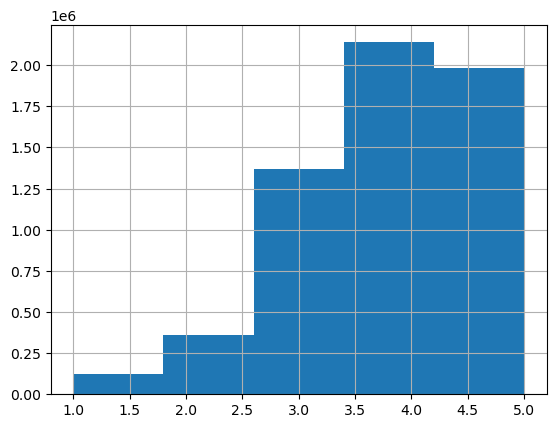

In [46]:
df_ratings["rating"].hist(bins=5)

In [47]:
df_books_100k = df_books[df_books["quantidade_avaliacoes"] > 100000]

In [50]:
df_livros_avaliados.to_csv("livros_avaliados.csv", index=False)